In [1]:
import pandas as pd
import numpy as np
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
from pathlib import Path
from prudence_funct import hourly_rolling_cap, apply_soft_cap, plot_prudence_component, stationary_bootstrap_indices, revenue_scenarios_stationary_bootstrap, capping_stats

data_folder = Path.cwd()/"CSV"

In [2]:
# Data Import: FCR (capacity price)
# Goal: Create an hourly time series of NL FCR settlement capacity price (EUR/MW).
# The source file encodes hourly products via PRODUCTNAME, which is expanded
# into one row per hour.
fcr = pd.read_csv(data_folder/"FCR_NL2024.csv")
col = "NETHERLANDS_SETTLEMENTCAPACITY_PRICE_[EUR/MW]"

# Set missing values to NaN
fcr[col] = pd.to_numeric(
    fcr[col].replace("-", np.nan),
    errors="coerce"
)

n_missing = fcr[col].isna().sum()
print("Number of missing prices:", n_missing)

# Data cleaning / hourly expansion
# Input:
#   - DATE_FROM is a date/time anchor for the product day.
#   - PRODUCTNAME contains a pattern like "HH_HH" indicating start/end hour.
# Transform:
#   - Extract start and end hours, create a list of covered hours,
#   - explode to one row per hour,
#   - create a proper UTC datetime index.
fcr["DATE_FROM"] = pd.to_datetime(fcr["DATE_FROM"])
hours = fcr["PRODUCTNAME"].str.extract(r"(\d{2})_(\d{2})").astype(int)
fcr["start_hour"] = hours[0]
fcr["end_hour"] = hours[1]
fcr["hour"] = fcr.apply(
    lambda row: list(range(row["start_hour"], row["end_hour"])),
    axis=1
)
fcr = fcr.explode("hour")
fcr["datetime"] = fcr["DATE_FROM"] + pd.to_timedelta(fcr["hour"], unit="h")
# Drop helper columns
fcr = fcr.drop(columns=["PRODUCTNAME", "start_hour", "end_hour", "hour"])
# Keep only the price column and rename
# Output:
#   hourly indexed DataFrame with one column: "FCR_capacity_EUR/MW"
fcr["datetime"] = pd.to_datetime(fcr["datetime"], utc=True)
fcr = fcr.sort_values("datetime").set_index("datetime")
fcr = (
    fcr[["NETHERLANDS_SETTLEMENTCAPACITY_PRICE_[EUR/MW]"]]
    .rename(columns={"NETHERLANDS_SETTLEMENTCAPACITY_PRICE_[EUR/MW]": "FCR_capacity_EUR/MW"})
)
print(fcr.head())

Number of missing prices: 156
                           FCR_capacity_EUR/MW
datetime                                      
2024-01-01 00:00:00+00:00                  NaN
2024-01-01 01:00:00+00:00                  NaN
2024-01-01 02:00:00+00:00                  NaN
2024-01-01 03:00:00+00:00                  NaN
2024-01-01 04:00:00+00:00                  NaN


In [3]:
# Data Import: aFRR Capacity
# Goal: hourly series of aFRR capacity price for upward direction (EUR/MW).
# Method: parse timestamps -> set index -> resample hourly mean.
afrr_cap = pd.read_csv(data_folder / "capacity_aFRR_NL.csv")

afrr_cap["datetime"] = pd.to_datetime(afrr_cap["datetime"], utc=True)
afrr_cap["Down"] = pd.to_numeric(afrr_cap["Down"])

afrr_cap = (
    afrr_cap
    .set_index("datetime")
    .resample("1h")["Down"].mean()
    .to_frame(name="aFRR_capacity_DOWN_EUR/MW")
)

print(afrr_cap.head())

                           aFRR_capacity_DOWN_EUR/MW
datetime                                            
2023-12-31 23:00:00+00:00                       16.9
2024-01-01 00:00:00+00:00                       16.9
2024-01-01 01:00:00+00:00                       16.9
2024-01-01 02:00:00+00:00                       16.9
2024-01-01 03:00:00+00:00                       16.9


In [ ]:
# Combine both on their datetime index and build "best-case" revenue totals (EUR/MW)
best_case_revenue = pd.concat(
    [fcr, afrr_cap],
    axis=1
)

# Make sure columns are in logical order for readability
best_case_revenue = best_case_revenue[
    ["FCR_capacity_EUR/MW",
     "aFRR_capacity_DOWN_EUR/MW"]
]

# Add sum of FCR + aFRR capacity
best_case_revenue["total_capacity_revenue_EUR/MW"] = (
    best_case_revenue["FCR_capacity_EUR/MW"]
    + best_case_revenue["aFRR_capacity_DOWN_EUR/MW"]
)



print(best_case_revenue.head())


                           FCR_capacity_EUR/MW  aFRR_capacity_DOWN_EUR/MW  \
datetime                                                                    
2023-12-31 23:00:00+00:00                  NaN                       16.9   
2024-01-01 00:00:00+00:00                  NaN                       16.9   
2024-01-01 01:00:00+00:00                  NaN                       16.9   
2024-01-01 02:00:00+00:00                  NaN                       16.9   
2024-01-01 03:00:00+00:00                  NaN                       16.9   

                           total_capacity_revenue_EUR/MW  
datetime                                                  
2023-12-31 23:00:00+00:00                            NaN  
2024-01-01 00:00:00+00:00                            NaN  
2024-01-01 01:00:00+00:00                            NaN  
2024-01-01 02:00:00+00:00                            NaN  
2024-01-01 03:00:00+00:00                            NaN  


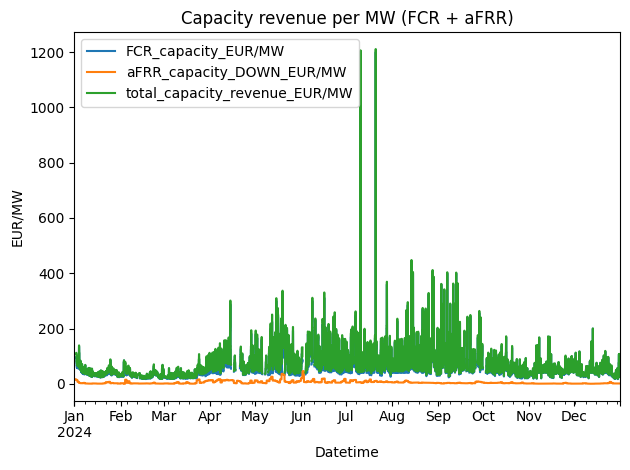

     FCR_capacity_EUR/MW  aFRR_capacity_DOWN_EUR/MW  \
min                17.21                       0.38   
max              1200.00                      46.15   

     total_capacity_revenue_EUR/MW  
min                          18.75  
max                        1210.91  


In [ ]:
# Visual sanity check: raw revenue series
# capacity-only revenues (FCR, aFRR cap, and their sum)
cap = best_case_revenue[
    ["FCR_capacity_EUR/MW", "aFRR_capacity_DOWN_EUR/MW", "total_capacity_revenue_EUR/MW"]
].dropna(how="all")

fig, ax = plt.subplots()
cap.plot(ax=ax)
ax.set_title("Capacity revenue per MW (FCR + aFRR)")
ax.set_ylabel("EUR/MW")
ax.set_xlabel("Datetime")
plt.tight_layout()
plt.show()


# Basic range diagnostics
min_max = best_case_revenue.agg(['min', 'max'])
print(min_max)

In [7]:
# Prudence: rolling soft caps (hour-of-day conditional)
# Goal:
#   Reduce exposure to spike-driven overstatement by applying rolling quantile
#   caps separately by hour-of-day, then applying a soft cap transform.
#
# How to read parameters:
#   WINDOW:
#     lookback window used to estimate the rolling distribution per hour-of-day
#   MINP_BY_HOUR:
#     minimum observations required within each hour bucket for cap estimation
#   q (in hourly_rolling_cap):
#     cap percentile; higher q => less strict (cap is lower)
#   alpha (in apply_soft_cap):
#     softness / severity; higher alpha => more strict reduction above cap
#
# Output columns:
#   - *_prudent: prudence-adjusted series (EUR/MW)
#   - cap_*: computed cap series (EUR/MW)
df = best_case_revenue.copy()
df["hour"] = df.index.hour

# Choose prudence settings
WINDOW = "60D"
MINP_BY_HOUR = 14

# Component-specific caps - Increase q for less strict capping (higher floor)
cap_fcr_down = hourly_rolling_cap(df, "FCR_capacity_EUR/MW", WINDOW, q=0.97, min_periods=MINP_BY_HOUR)
cap_afrr_cap_down = hourly_rolling_cap(df, "aFRR_capacity_DOWN_EUR/MW", WINDOW, q=0.98, min_periods=MINP_BY_HOUR)

# Apply caps - Increase alpha for more strict capping (higher floor)
best_case_revenue["FCR_capacity_prudent_down"] = apply_soft_cap(df["FCR_capacity_EUR/MW"], cap_fcr_down, alpha=0.10)
best_case_revenue["aFRR_capacity_DOWN_prudent"] = apply_soft_cap(df["aFRR_capacity_DOWN_EUR/MW"], cap_afrr_cap_down, alpha=0.10)

# Recompute prudent total revenue
best_case_revenue["total_capacity_revenue_prudent_down"] = (
    best_case_revenue["FCR_capacity_prudent_down"] +
    best_case_revenue["aFRR_capacity_DOWN_prudent"]
)


# Store for reference
best_case_revenue = best_case_revenue.copy()
best_case_revenue["cap_fcr_down"] = cap_fcr_down
best_case_revenue["cap_afrr_cap_down"] = cap_afrr_cap_down


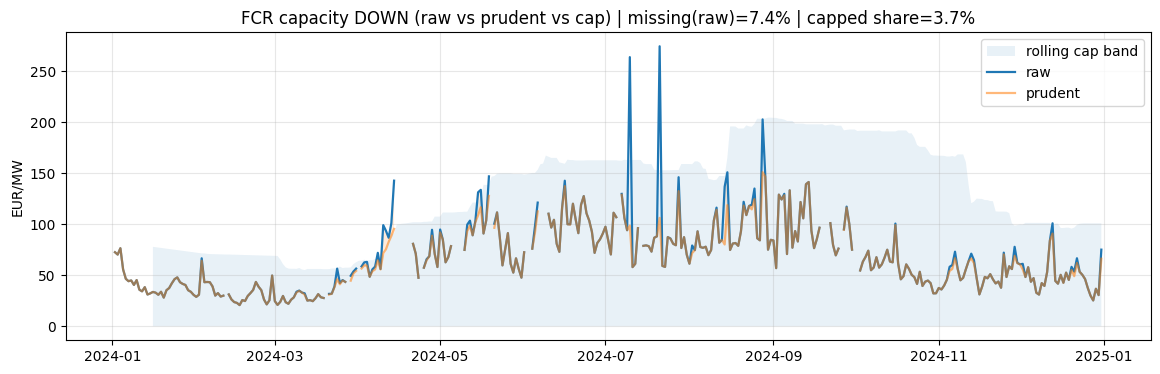

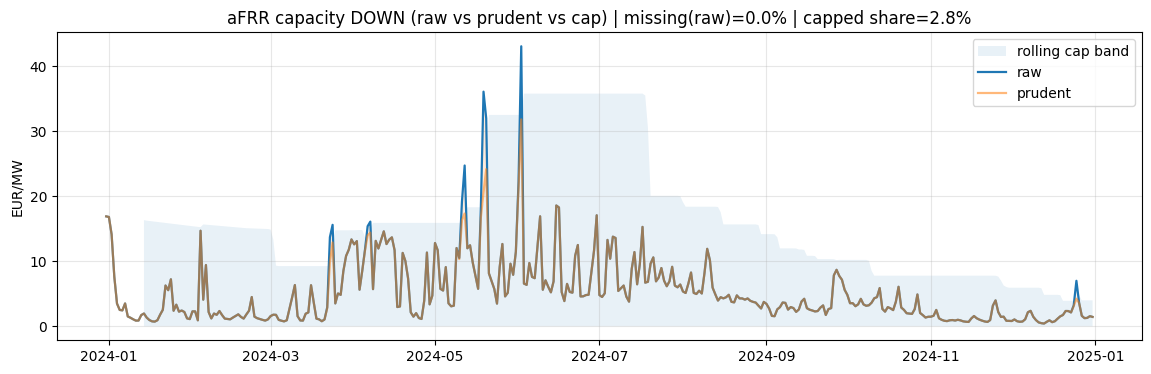

FCR: {'cap_defined_share': np.float64(0.9589072282299373), 'exceed_count': 524, 'exceed_share_of_defined': 0.06697341513292433, 'avg_exceedance': 44.004693129771}
aFRR cap: {'cap_defined_share': np.float64(0.9617529880478087), 'exceed_count': 242, 'exceed_share_of_defined': 0.028642442892650017, 'avg_exceedance': 6.621902995867766}


In [8]:
# Prudence visualization: raw vs prudent vs cap
# These plots show:
#   - raw series (what occurred),
#   - prudent series,
#   - cap series (the rolling threshold binding during spikes).
# Resampling to daily is used for readability.

# 3 separate plots for FCR, afrr cap, afrr activation
plot_prudence_component(
    best_case_revenue,
    raw_col="FCR_capacity_EUR/MW",
    prudent_col="FCR_capacity_prudent_down",
    cap_col="cap_fcr_down",
    title="FCR capacity DOWN (raw vs prudent vs cap)",
    resample="D"
)

plot_prudence_component(
    best_case_revenue,
    raw_col="aFRR_capacity_DOWN_EUR/MW",
    prudent_col="aFRR_capacity_DOWN_prudent",
    cap_col="cap_afrr_cap_down",
    title="aFRR capacity DOWN (raw vs prudent vs cap)",
    resample="D"
)


# Prudence diagnostics
print("FCR:", capping_stats(best_case_revenue["FCR_capacity_EUR/MW"], cap_fcr_down))
print("aFRR cap:", capping_stats(best_case_revenue["aFRR_capacity_DOWN_EUR/MW"], cap_afrr_cap_down))

In [10]:
# Simulated annual revenue scenarios via stationary bootstrap
# Goal:
#   Generate many plausible annual revenue paths from the prudent total revenue
#   series while preserving autocorrelation (clustering) using stationary bootstrap.
#
# Input:
#   s: hourly time series of prudent total revenue (EUR/MW)
#   n_sims: number of simulated annual paths
#   exp_block_len: expected block length (hours) controlling dependency retention
#
# Output:
#   annual_totals: simulated annual total revenue per MW (EUR/MW-year)
#
# Financial interpretation:
#   - P50: median annual revenue (central expectation under historical regime)
#   - P90 exceedance: downside (10th percentile) used as a conservative case

# Example: simulate annual totals from prudent revenue per MW
s_down = best_case_revenue["total_capacity_revenue_prudent_down"].dropna()

sims_down = revenue_scenarios_stationary_bootstrap(s_down, n_sims=2000, exp_block_len=48)
annual_totals_down = sims_down.sum(axis=1)  # EUR/MW-year for downward market

# Get the percentiles for annual downward revenue (P50, P90)
p50_down = np.quantile(annual_totals_down, 0.50)
p90_down = np.quantile(annual_totals_down, 0.10)  # 90% exceedance => 10th percentile
print("Annual downward revenue EUR/MW: P50=", p50_down, " P90=", p90_down)


Annual downward revenue EUR/MW: P50= 572121.6337575  P90= 541389.249148
